In [17]:
import duckdb

conn = duckdb.connect("../tmp/polymarket.db")
conn.execute("PRAGMA threads=8")
conn.execute("PRAGMA enable_object_cache=true")

market_path = "../Data/data/polymarket/markets/markets_*.parquet"
trade_path = "../Data/data/polymarket/trades/trades_*.parquet"
block_path = "../Data/data/polymarket/blocks/blocks_*.parquet"

In [18]:
# get df of trades
trades = conn.execute(f"""
    SELECT t.*, b.timestamp
    FROM trades_sampled AS t
    LEFT JOIN '{block_path}' AS b
        ON t.block_number = b.block_number
    ORDER BY t.block_number DESC
""").df()

# get dictionary of token to question
no_token_to_question = conn.execute("SELECT no_token, question FROM markets").df()
no_token_to_question_dict = dict(zip(no_token_to_question.no_token, no_token_to_question.question))
yes_token_to_question = conn.execute("SELECT yes_token, question FROM markets").df()
yes_token_to_question_dict = dict(zip(yes_token_to_question.yes_token, yes_token_to_question.question))

# get dictionary of token to implied outcome
token_to_implied_outcome = conn.execute("SELECT token, implied_outcome FROM tokens").df()
token_to_implied_outcome_dict = dict(zip(token_to_implied_outcome.token, token_to_implied_outcome.implied_outcome))

In [19]:
from datetime import datetime

class Trade:
    def __init__(self, trade, trader):
        token = trade.maker_asset_id if trade.maker_asset_id != '0' else trade.taker_asset_id

        # true if the trader made the trade as a maker, false if the trader made the trade as a taker
        is_maker = trade.maker == trader

        # true if they bought the contract, false if they sold the contract
        bought_contract = (is_maker and trade.maker_asset_id != '0') or (not is_maker and trade.maker_asset_id == '0')

        # text description of the question this trade is associated with
        question = yes_token_to_question_dict[token] if token in yes_token_to_question_dict else no_token_to_question_dict[token]

        # true if this trade is associated with a yes token, false if this trade is associated with a no token
        is_yes_token = token in yes_token_to_question_dict

        # implied outcome OF THE TOKEN -- i.e if a no token and the question resolves to True, the implied outcome is False
        implied_token_outcome = token_to_implied_outcome_dict[token] if token in token_to_implied_outcome_dict else None

        # whether the question associated with the token resolved to true
        implied_question_outcome = (is_yes_token and implied_token_outcome) or (not is_yes_token and not implied_token_outcome)

        dollar_amount = (trade.maker_amount if trade.maker_asset_id == '0' else trade.taker_amount) / 1e6
        contract_amount = (trade.maker_amount if trade.maker_asset_id != '0' else trade.taker_amount) / 1e6
        odds = dollar_amount / contract_amount if contract_amount != 0 else 0

        won = (bought_contract and implied_token_outcome) or (not bought_contract and not implied_token_outcome)

        time = datetime.strptime(trade.timestamp_1, "%Y-%m-%dT%H:%M:%SZ")

        profit = self.compute_profit(implied_token_outcome, odds, dollar_amount, bought_contract)

        self.data = {
            'token': token,
            'is_maker': is_maker,
            'bought_contract': bought_contract,
            'question': question,
            'is_yes_token': is_yes_token,
            'implied_token_outcome': implied_token_outcome,
            'implied_question_outcome': implied_question_outcome,
            'dollar_amount': dollar_amount,
            'contract_amount': contract_amount,
            'odds': odds,
            'won': won,
            'time': time,
            'profit': profit
        }

    def compute_profit(self, implied_token_outcome, odds, dollar_amount, bought_contract):
        # if buying and the token resolves to true, profit is (1 - odds) * dollar_amount
        # if buying and the token resolves to false, profit is -dollar_amount
        # if selling and the token resolves to true, profit is (odds - 1) * dollar_amount
        # if selling and the token resolves to false, profit is dollar_amount
        if bought_contract and implied_token_outcome:
            return (1 - odds) * dollar_amount
        elif bought_contract and not implied_token_outcome:
            return -dollar_amount
        elif not bought_contract and implied_token_outcome:
            return (odds - 1) * dollar_amount
        elif not bought_contract and not implied_token_outcome:
            return dollar_amount

In [47]:
# create a set of all traders in the traders_sampled table
traders = set(conn.execute("SELECT trader FROM traders_sampled").df().trader)

In [48]:
from collections import defaultdict
from tqdm.auto import tqdm

trader_stats = defaultdict(list)

for trade in tqdm(trades.itertuples(), total=len(trades)):
    try:
        if trade.maker in traders:
            trader_stats[trade.maker].append(Trade(trade, trade.maker))
        if trade.taker in traders:
            trader_stats[trade.taker].append(Trade(trade, trade.taker))
    except Exception:
        continue

  0%|          | 0/305708 [00:00<?, ?it/s]

In [ ]:
def extract_trader_stats(trades : list[Trade]):
    # Win rate
    # Avg trade size
    # Total trade volume
    # Total trade number
    # Frequency (Trades/day) (trades / number of days between first and last trade)
    # Net gains/loss
    # Avg odds

    win_rate = sum([1 for trade in trades if trade.data['won']]) / len(trades) if len(trades) > 0 else 0
    avg_trade_size = sum([trade.data['dollar_amount'] for trade in trades]) / len(trades) if len(trades) > 0 else 0
    total_trade_volume = sum([trade.data['dollar_amount'] for trade in trades])
    total_trade_number = len(trades)
    frequency = total_trade_number / ((max([trade.data['time'] for trade in trades]) - min([trade.data['time'] for trade in trades])).days + 1) if len(trades) > 1 else 0
    net_gains_loss = sum([trade.data['profit'] for trade in trades])
    avg_odds = sum([trade.data['odds'] for trade in trades]) / len(trades) if len(trades) > 0 else 0

    return {
        'win_rate': win_rate,
        'avg_trade_size': avg_trade_size,
        'total_trade_volume': total_trade_volume,
        'total_trade_number': total_trade_number,
        'frequency': frequency,
        'net_gains_loss': net_gains_loss,
        'avg_odds': avg_odds
    }

trader_stats = {trader: extract_trader_stats(trades) for trader, trades in tqdm(trader_stats.items(), total=len(trader_stats))}

  0%|          | 0/464 [00:00<?, ?it/s]

In [50]:
for k, v in list(trader_stats.items())[:5]:
    print(f"https://polymarket.com/{k}")
    for stat, value in v.items():
        print(f"  {stat}: {value}")
    print()

https://polymarket.com/0x18d7b544543afCe04C17EE133bFcae703872e02B
  win_rate: 0.7724550898203593
  avg_trade_size: 50.6131504730539
  total_trade_volume: 8452.396129
  total_trade_number: 167
  frequency: 2.5303030303030303
  net_gains_loss: 193.84550169234868
  avg_odds: 0.6448842111406546

https://polymarket.com/0xd9Fb2ecC4926efe32a4B0232e9c15bdd4dDF74F3
  win_rate: 0.5326797385620915
  avg_trade_size: 23.768552901960785
  total_trade_volume: 14546.354376
  total_trade_number: 612
  frequency: 10.551724137931034
  net_gains_loss: -870.3655449313214
  avg_odds: 0.5629246109832473

https://polymarket.com/0xCA15832b58674FC4e9D7E87bff859c4B94629b50
  win_rate: 0.7898146534193249
  avg_trade_size: 8.306900895648132
  total_trade_volume: 285940.14263
  total_trade_number: 34422
  frequency: 77.87782805429865
  net_gains_loss: 21836.206702466658
  avg_odds: 0.5437999445816335

https://polymarket.com/0xC6AdF660e35CA4103559Aa9B100217C305eD5f3C
  win_rate: 0.4983780978331387
  avg_trade_size: 

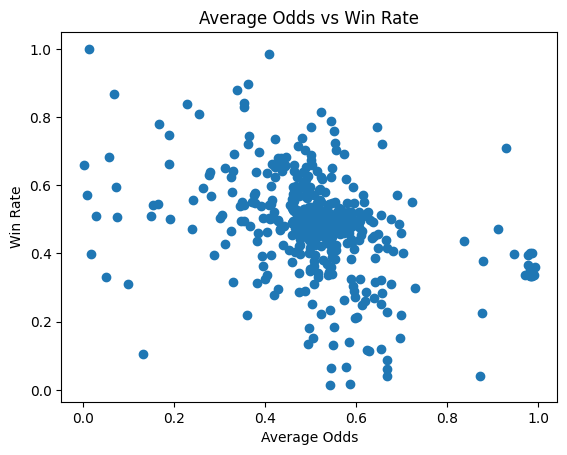

In [51]:
import matplotlib.pyplot as plt

# graph average odds vs win rate
avg_odds = [stats['avg_odds'] for stats in trader_stats.values()]
win_rates = [stats['win_rate'] for stats in trader_stats.values()]
plt.scatter(avg_odds, win_rates)
plt.xlabel('Average Odds')
plt.ylabel('Win Rate')
plt.title('Average Odds vs Win Rate')
plt.show()

In [52]:
# create a csv of trader stats
import csv

with open('trader_stats.csv', 'w', newline='') as csvfile:
    stats = ['trader', 'win_rate', 'avg_trade_size', 'total_trade_volume', 'total_trade_number', 'frequency', 'net_gains_loss', 'avg_odds']
    writer = csv.DictWriter(csvfile, fieldnames=stats)

    writer.writeheader()
    for trader, stats in trader_stats.items():
        row = {'trader': trader}
        row.update(stats)
        writer.writerow(row)